In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.preprocessing import ICA
import pandas as pd
import seaborn as sns
from mne.stats import permutation_cluster_test
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# Stier
bdf_path = r"C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/Main_data/LuChris_1.bdf"
csv_path = r"C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/Main_data/data_p9876_20260508_1018.csv"

# Indlæsning af data
raw = mne.io.read_raw_bdf(bdf_path, preload=True)   # .bdf
raw.resample(256)
raw = raw.notch_filter(50)
raw.set_eeg_reference('average', projection=False)
df = pd.read_csv(csv_path)                          # .csv

Extracting BDF parameters from C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/Main_data/LuChris_1.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6557695  =      0.000 ...  3202.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filte

In [4]:

import numpy as np
import pandas as pd
import mne

# ==============================================================================
# 1. 1-TIL-1 OVERSÆTTELSE AF R-SCRIPTETS CTW FUNKTION
# ==============================================================================
def calc_context_probabilities_ctw(seq, max_depth=10):
    n = len(seq)
    p_1_est = np.zeros(n)
    
    seq_clean = [0 if pd.isna(x) else int(x) for x in seq]
    seq_str = [str(x) for x in seq_clean]
    
    for i in range(1, n + 1):
        if i == 1:
            p_1_est[i - 1] = 0.5
            continue
            
        current_max_depth = min(i - 1, max_depth)
        p_levels = np.zeros(current_max_depth + 1)
        
        for d in range(0, current_max_depth + 1):
            hits_1, hits_0 = 0, 0
            
            if d == 0:
                past_seq = seq_str[0 : i - 1]
                hits_1 = past_seq.count("1")
                hits_0 = past_seq.count("0")
            else:
                current_context = "_".join(seq_str[(i - d - 1) : (i - 1)])
                for j in range(d + 1, i):
                    hist_context = "_".join(seq_str[(j - d - 1) : (j - 1)])
                    if hist_context == current_context:
                        if seq_str[j - 1] == "1":
                            hits_1 += 1
                        else:
                            hits_0 += 1
                            
            p_levels[d] = (hits_1 + 1) / (hits_1 + hits_0 + 2)
            
        p_blend = p_levels[current_max_depth]
        
        if current_max_depth > 0:
            for d in range(current_max_depth, 0, -1):
                p_parent = p_levels[d - 1]
                p_blend = 0.5 * p_parent + 0.5 * p_blend
                
        p_1_est[i - 1] = p_blend
        
    return p_1_est

# ==============================================================================
# 2. MUTATE CSV: BEREGN CTW SURPRISAL PÅ DEN FULDE SEKVENS (Med log-transform)
# ==============================================================================
print("Sorterer data og beregner CTW Surprisal præcis som i R...")

# Sørg for at data er sorteret korrekt
df = df.sort_values(by=['participant_id', 'block_num', 'trial_num']).reset_index(drop=True)
df['stim_binary'] = df['stimulus_state'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'standard' else 1)
df['surprisal'] = np.nan 

for block_id in df['block_num'].unique():
    idx = df.index[df['block_num'] == block_id]
    seq = df.loc[idx, 'stim_binary'].values
    
    # Beregn sandsynligheden for at næste stimulus er deviant
    p_stim_dev = calc_context_probabilities_ctw(seq, max_depth=10)
    
    # Her sker log-transformationen for at få Shannon Information (Bits)
    surprisals = np.where(seq == 1, -np.log2(p_stim_dev), -np.log2(1 - p_stim_dev))
    df.loc[idx, 'surprisal'] = surprisals

# ==============================================================================
# 3. MUTATE CSV: EKSTRAHER SINGLE-TRIAL AMPLITUDER FØR RENSNING
# ==============================================================================
print("Muterer DataFrame med single-trial amplituder for MMN, P3a, P3b og P300...")

events_temp = mne.find_events(raw, stim_channel='Status', verbose=False)
if len(events_temp) > len(df):
    events_temp = events_temp[-len(df):]

epochs_temp = mne.Epochs(raw, events_temp, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0), preload=True, verbose=False)
temp_data = epochs_temp.get_data() 

# ==============================================================================
# 3. MUTATE CSV: EKSTRAHER SINGLE-TRIAL AMPLITUDER (MODALITETS-SPECIFIKKE ROIs)
# ==============================================================================
print("Muterer DataFrame med modalitets-specifikke amplituder...")

events_temp = mne.find_events(raw, stim_channel='Status', verbose=False)
if len(events_temp) > len(df):
    events_temp = events_temp[-len(df):]

epochs_temp = mne.Epochs(raw, events_temp, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0), preload=True, verbose=False)
temp_data = epochs_temp.get_data() 

# Vi opbygger ROIs dynamisk alt efter om blokken er AS, SV eller AV
rois_by_modality = {
    'AS': {
        'MMN':  {'channels': ['Fz'],               'tmin': 0.100, 'tmax': 0.250},
        'P3a':  {'channels': ['Fz', 'FCz', 'Cz'],  'tmin': 0.250, 'tmax': 0.350},
        'P3b':  {'channels': ['Pz', 'CPz', 'POz'], 'tmin': 0.350, 'tmax': 0.550},
        'P300': {'channels': ['Cz'],               'tmin': 0.300, 'tmax': 0.500}
    },
    'SV': {
        'MMN':  {'channels': ['Oz'],               'tmin': 0.150, 'tmax': 0.250},
        'P3a':  {'channels': ['Fz', 'FCz', 'Cz'],  'tmin': 0.250, 'tmax': 0.350},
        'P3b':  {'channels': ['Pz', 'CPz', 'POz'], 'tmin': 0.350, 'tmax': 0.500},
        'P300': {'channels': ['Oz', 'Pz'],         'tmin': 0.300, 'tmax': 0.500}
    },
    'AV': {
        'MMN':  {'channels': ['Fz', 'FCz'],        'tmin': 0.150, 'tmax': 0.250}, 
        'P3a':  {'channels': ['Fz', 'FCz', 'Cz'],  'tmin': 0.250, 'tmax': 0.350},
        'P3b':  {'channels': ['Pz', 'CPz', 'POz'], 'tmin': 0.350, 'tmax': 0.550},
        'P300': {'channels': ['Pz', 'CPz', 'POz'], 'tmin': 0.300, 'tmax': 0.500}
    }
}

# Gør plads til værdierne i DataFramen med tomme kolonner
for roi in ['MMN', 'P3a', 'P3b', 'P300']:
    df[f'amp_{roi}'] = np.nan

# Løb igennem hver modalitet (AS, SV, AV)
for modality, rois in rois_by_modality.items():
    
    # Find rækkenumrene for alle trials i netop denne modalitet
    idx_mask = df['deviant_type'] == modality
    trial_indices = np.where(idx_mask)[0]
    
    if len(trial_indices) == 0:
        continue
        
    for roi_name, info in rois.items():
        # Find MNE's interne index for de specifikke kanaler
        ch_idxs = [epochs_temp.ch_names.index(ch) for ch in info['channels'] if ch in epochs_temp.ch_names]
        
        if ch_idxs:
            tmin_idx = epochs_temp.time_as_index(info['tmin'])[0]
            tmax_idx = epochs_temp.time_as_index(info['tmax'])[0]
            
            # Ekstraher amplitude KUN for de trials der matcher modaliteten
            # Snittet er: [Matchende_Trials, Kanaler, Tidsvindue]
            roi_signals = temp_data[trial_indices][:, ch_idxs, tmin_idx:tmax_idx]
            
            # Beregn gennemsnittet på tværs af tid og kanaler, og konvertér til µV
            mean_amplitudes = roi_signals.mean(axis=(1, 2)) * 1e6 
            
            # Tildel værdierne tilbage til de korrekte rækker i df
            df.loc[idx_mask, f'amp_{roi_name}'] = mean_amplitudes
        else:
            df.loc[idx_mask, f'amp_{roi_name}'] = 0.0

print("DataFrame er succesfuldt opdateret med modalitets-specifikke amplituder!")

for roi_name, info in rois.items():
    ch_idxs = [epochs_temp.ch_names.index(ch) for ch in info['channels'] if ch in epochs_temp.ch_names]
    if ch_idxs:
        tmin_idx = epochs_temp.time_as_index(info['tmin'])[0]
        tmax_idx = epochs_temp.time_as_index(info['tmax'])[0]
        roi_signals = temp_data[:, ch_idxs, tmin_idx:tmax_idx]
        mean_amplitudes = roi_signals.mean(axis=(1, 2)) * 1e6 
        df[f'amp_{roi_name}'] = mean_amplitudes
    else:
        df[f'amp_{roi_name}'] = 0.0

# ==============================================================================
# 4. DATA CLEANING PIPELINE OG MNE EPOCHS
# ==============================================================================
print("\nStarter den officielle datarensning...")

raw_ica = raw.copy().filter(l_freq=1.0, h_freq=40.0)
ica = mne.preprocessing.ICA(n_components=20, random_state=42, max_iter='auto')
ica.fit(raw_ica, decim=3)

eog_channels = ['Fp1', 'Fp2', 'Fpz']
try:
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
    print(f"ICA fandt blink i komponent(er): {eog_indices}")
    ica.exclude = eog_indices
except Exception as e:
    print("Kunne ikke finde EOG automatisk.")

raw_clean = raw.copy().filter(l_freq=0.1, h_freq=40.0)
ica.apply(raw_clean)

events = mne.find_events(raw_clean, stim_channel='Status')
if len(events) > len(df):
    events = events[-len(df):]

tmin, tmax = -0.2, 0.8
reject_criteria = dict(eeg=150e-6)

# MNE klipper dataen og parrer den med vores log-transformerede metadata
epochs = mne.Epochs(
    raw_clean,
    events,
    metadata = df, 
    tmin=tmin,
    tmax=tmax,
    baseline=(tmin, 0), 
    preload=True,
    reject=reject_criteria
)

print(epochs.drop_log_stats())

# Til sidst filtrerer vi Træningsblokke og forkerte svar FRA i de færdige epochs
epochs_correct = epochs["block_type != 'Training_Static' and block_type != 'Training_Dynamic' and correct == True"]
print("\nData er klar! Surprisal og amplituder ligger nu klar i epochs_correct.metadata.")

Sorterer data og beregner CTW Surprisal præcis som i R...
Muterer DataFrame med single-trial amplituder for MMN, P3a, P3b og P300...
Muterer DataFrame med modalitets-specifikke amplituder...
DataFrame er succesfuldt opdateret med modalitets-specifikke amplituder!

Starter den officielle datarensning...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 10

In [5]:
blocks_to_exclude = [1,2,3,4,5,6,7,11,15,19,23,27]
epochs_main = epochs[f"block_num not in {blocks_to_exclude}"]
epochs_correct = epochs_main["correct == True"]
print(f"Beholder {len(epochs_correct)} trials til selve ERP analysen.")

Beholder 998 trials til selve ERP analysen.


Generating 3 separate plots with separate R² and intercept (height) difference...


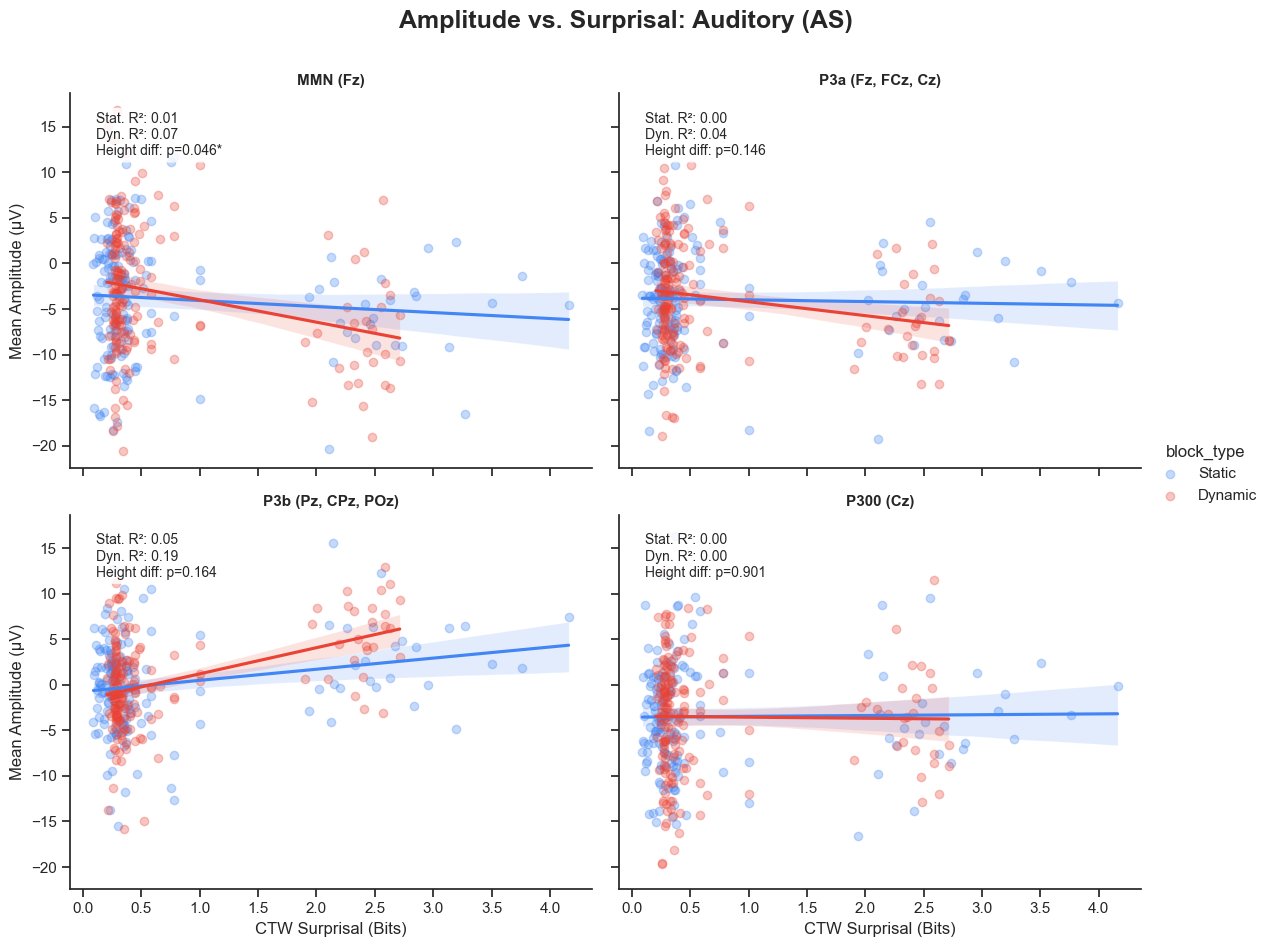

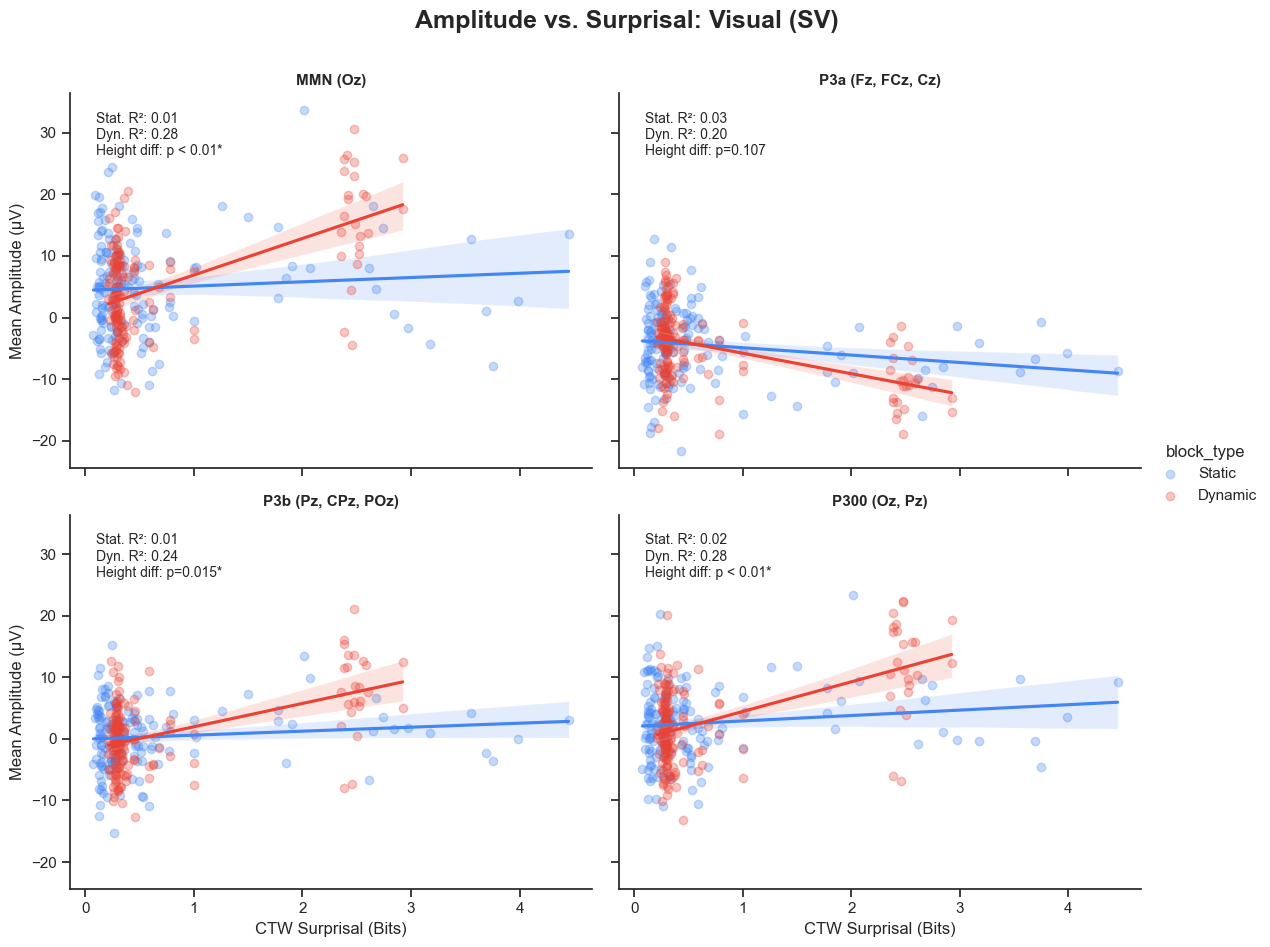

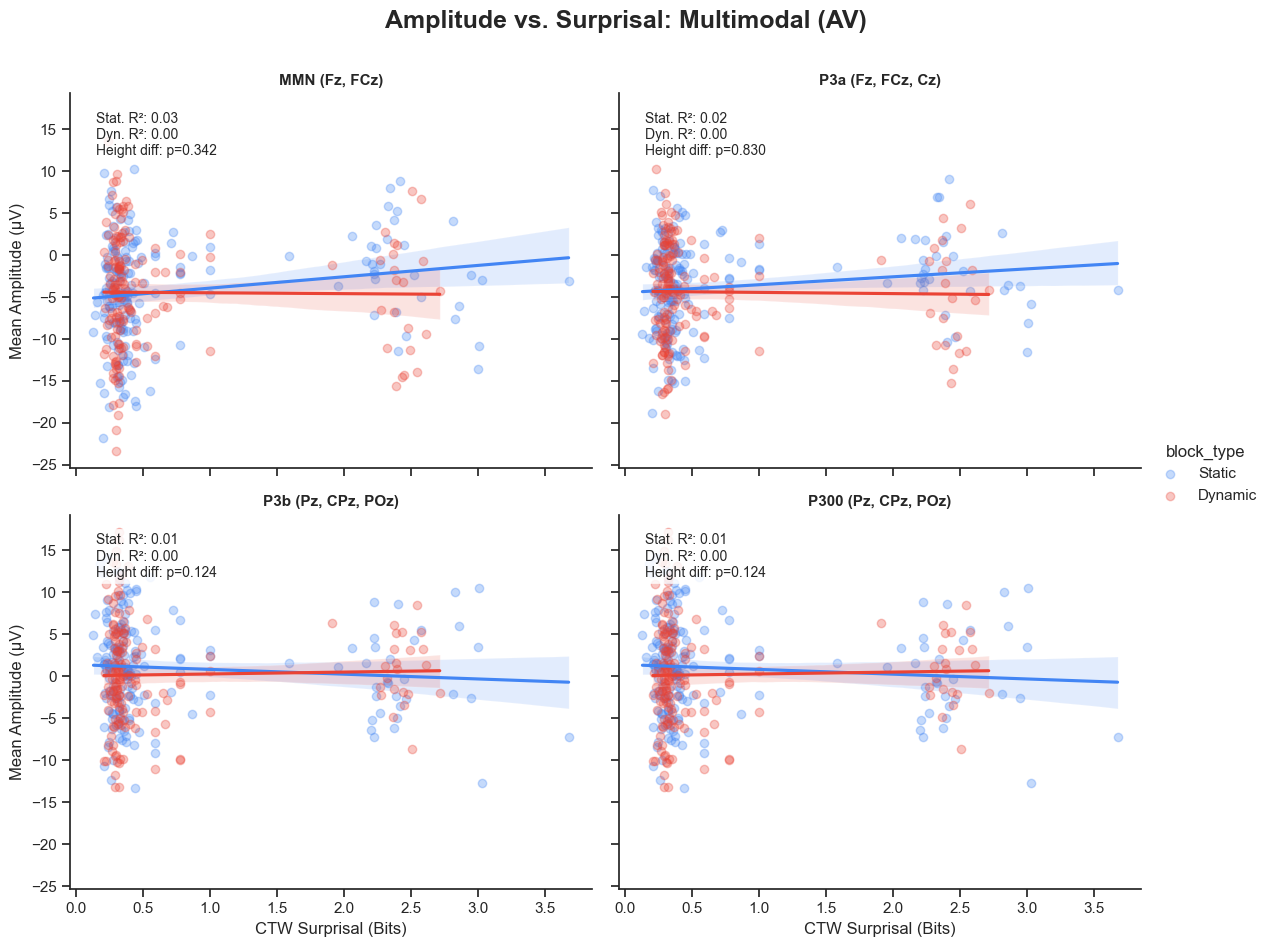

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf

print("Generating 3 separate plots with separate R² and intercept (height) difference...")

df_plot = epochs_correct.metadata.copy()
df_plot['deviant_type'] = df_plot['deviant_type'].replace({'VS': 'SV'})

# Define the channels for each modality
rois_by_modality = {
    'AS': {
        'MMN':  ['Fz'],
        'P3a':  ['Fz', 'FCz', 'Cz'],
        'P3b':  ['Pz', 'CPz', 'POz'],
        'P300': ['Cz']
    },
    'SV': {
        'MMN':  ['Oz'],
        'P3a':  ['Fz', 'FCz', 'Cz'],
        'P3b':  ['Pz', 'CPz', 'POz'],
        'P300': ['Oz', 'Pz']
    },
    'AV': {
        'MMN':  ['Fz', 'FCz'], 
        'P3a':  ['Fz', 'FCz', 'Cz'],
        'P3b':  ['Pz', 'CPz', 'POz'],
        'P300': ['Pz', 'CPz', 'POz']
    }
}

# 2. Helper function to format p-values
def format_p(p):
    if p < 0.01:
        return "p < 0.01"
    else:
        return f"p={p:.3f}"

# 3. Loop to generate 3 separate figures (AS, SV, AV)
for modality in ['AS', 'SV', 'AV']:
    
    df_mod = df_plot[df_plot['deviant_type'] == modality].copy()
    
    df_long = pd.melt(
        df_mod, 
        id_vars=['surprisal', 'block_type'], 
        value_vars=['amp_MMN', 'amp_P3a', 'amp_P3b', 'amp_P300'],
        var_name='ROI', 
        value_name='Amplitude_uV'
    )
    
    # Clean up ROI names and add channels from our dictionary
    def map_roi_name(roi_col):
        base_roi = roi_col.replace('amp_', '')
        channels = ", ".join(rois_by_modality[modality][base_roi])
        return f"{base_roi} ({channels})"
        
    df_long['ROI'] = df_long['ROI'].apply(map_roi_name)
    
    # Build the plot (2x2 grid per modality)
    sns.set_theme(style="ticks") 
    g = sns.lmplot(
        data=df_long,
        x='surprisal', 
        y='Amplitude_uV', 
        col='ROI',             
        hue='block_type',      
        col_wrap=2,            
        scatter_kws={'alpha': 0.3},
        height=4.5,            
        aspect=1.3,            
        palette={'Static': '#4285F4', 'Dynamic': '#EA4335'}
    )
    
    # 4. Add statistics manually (R² and Height Diff only)
    for ax, roi_name in zip(g.axes.flat, g.col_names):
        data_ax = df_long[df_long['ROI'] == roi_name].dropna(subset=['surprisal', 'Amplitude_uV'])
        
        if len(data_ax) > 5:
            text_lines = []
            
            d_stat = data_ax[data_ax['block_type'] == 'Static']
            d_dyn = data_ax[data_ax['block_type'] == 'Dynamic']
            
            try:
                # Calculate R² for Static
                if len(d_stat) > 2:
                    r_stat, _ = stats.pearsonr(d_stat['surprisal'], d_stat['Amplitude_uV'])
                    text_lines.append(f"Stat. R²: {r_stat**2:.2f}")
                    
                # Calculate R² for Dynamic
                if len(d_dyn) > 2:
                    r_dyn, _ = stats.pearsonr(d_dyn['surprisal'], d_dyn['Amplitude_uV'])
                    text_lines.append(f"Dyn. R²: {r_dyn**2:.2f}")
                
                # Fit ANCOVA model to test intercepts
                model = smf.ols("Amplitude_uV ~ surprisal * block_type", data=data_ax).fit()
                
                # Test for difference in Height / Intercept (Main effect of block_type)
                int_key = [k for k in model.pvalues.keys() if 'block_type' in k and ':' not in k][0]
                p_intercept = model.pvalues[int_key]
                sig_star_int = "*" if p_intercept < 0.05 else ""
                text_lines.append(f"Height diff: {format_p(p_intercept)}{sig_star_int}")
                
                # Print text box in the top left corner
                text_str = '\n'.join(text_lines)
                ax.text(0.05, 0.95, text_str, transform=ax.transAxes,
                        va='top', ha='left', fontsize=10, 
                        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.3'))
            except Exception:
                pass
    
    # Layout and labels
    g.set_axis_labels("CTW Surprisal (Bits)", "Mean Amplitude (µV)")
    g.set_titles(col_template="{col_name}", size=11, weight='bold') 
    sns.despine()
    
    modality_full = {'AS': 'Auditory (AS)', 'SV': 'Visual (SV)', 'AV': 'Multimodal (AV)'}[modality]
    g.fig.suptitle(f"Amplitude vs. Surprisal: {modality_full}", y=1.05, fontsize=18, fontweight='bold')
    
    plt.show()

Beregner streaks (kæder), kumulativt areal og gennemsnitlig ERP...


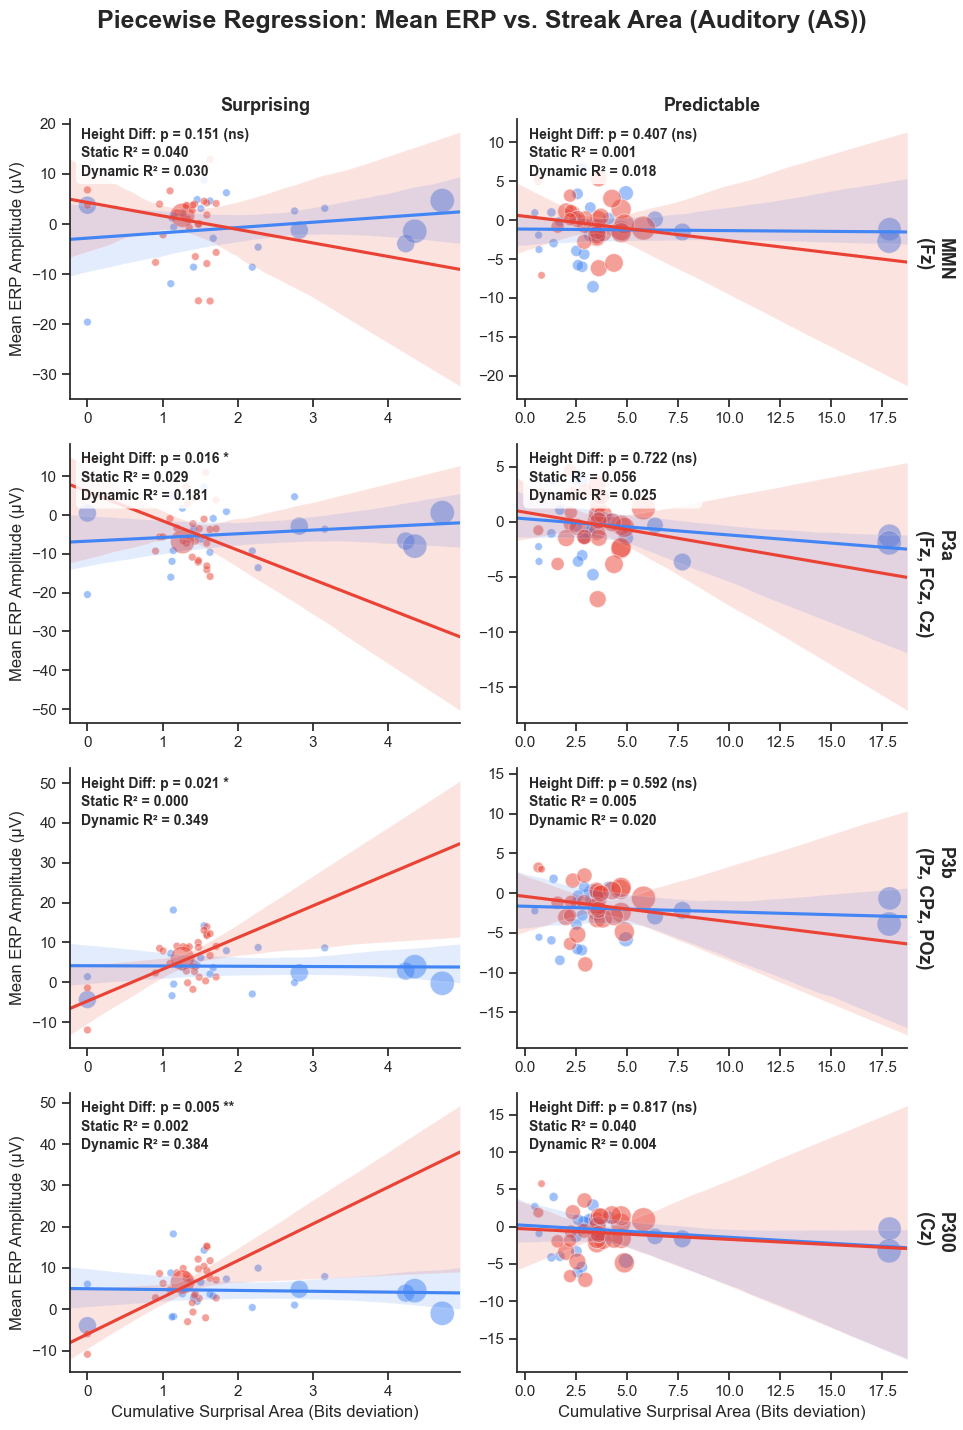

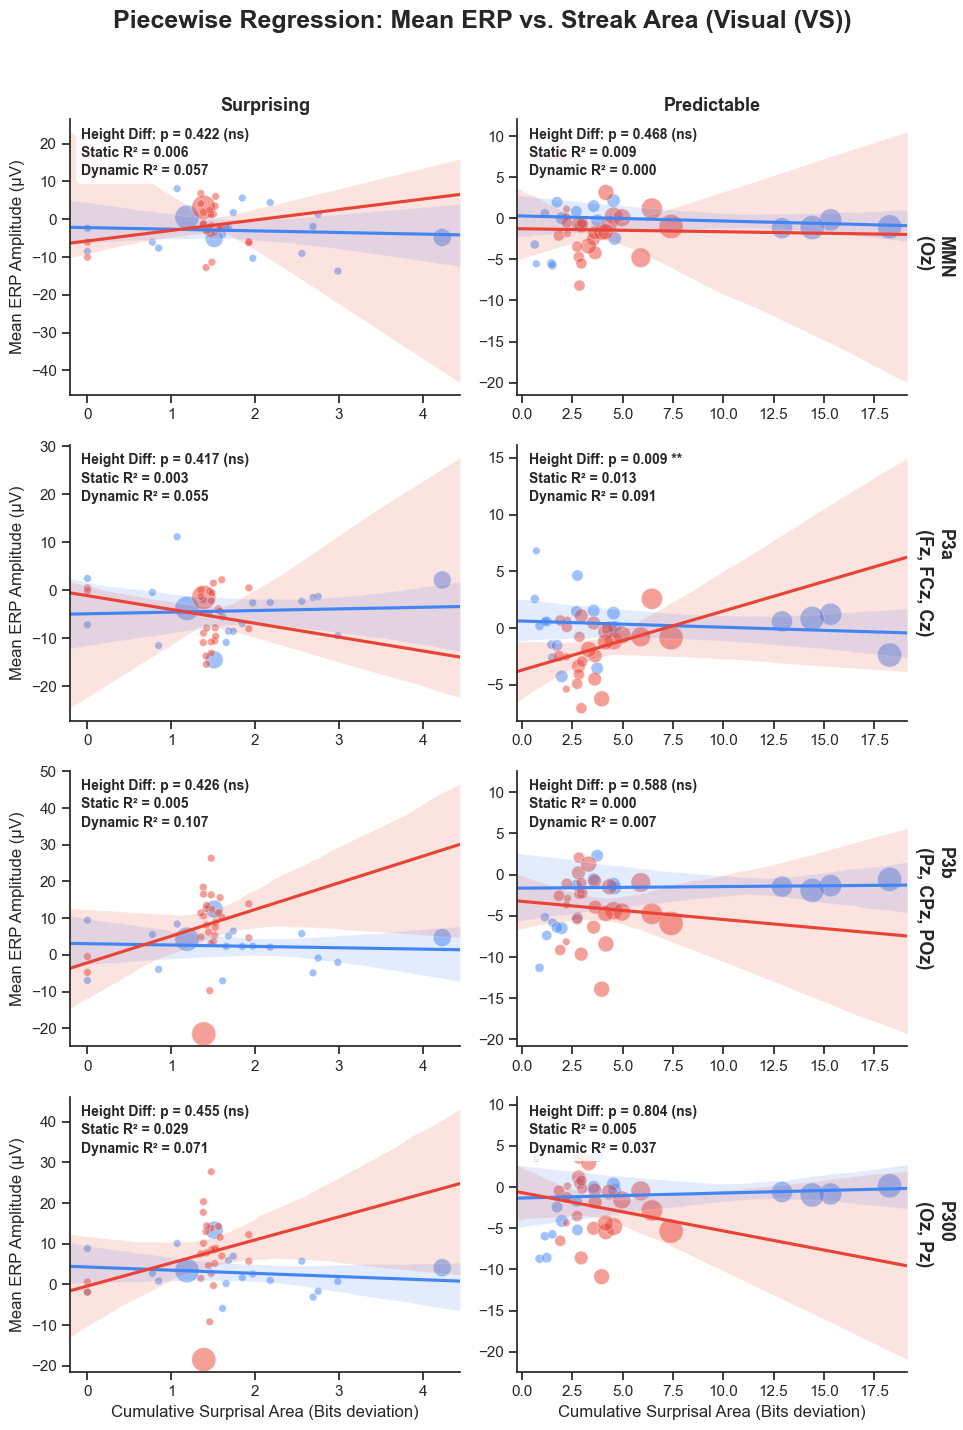

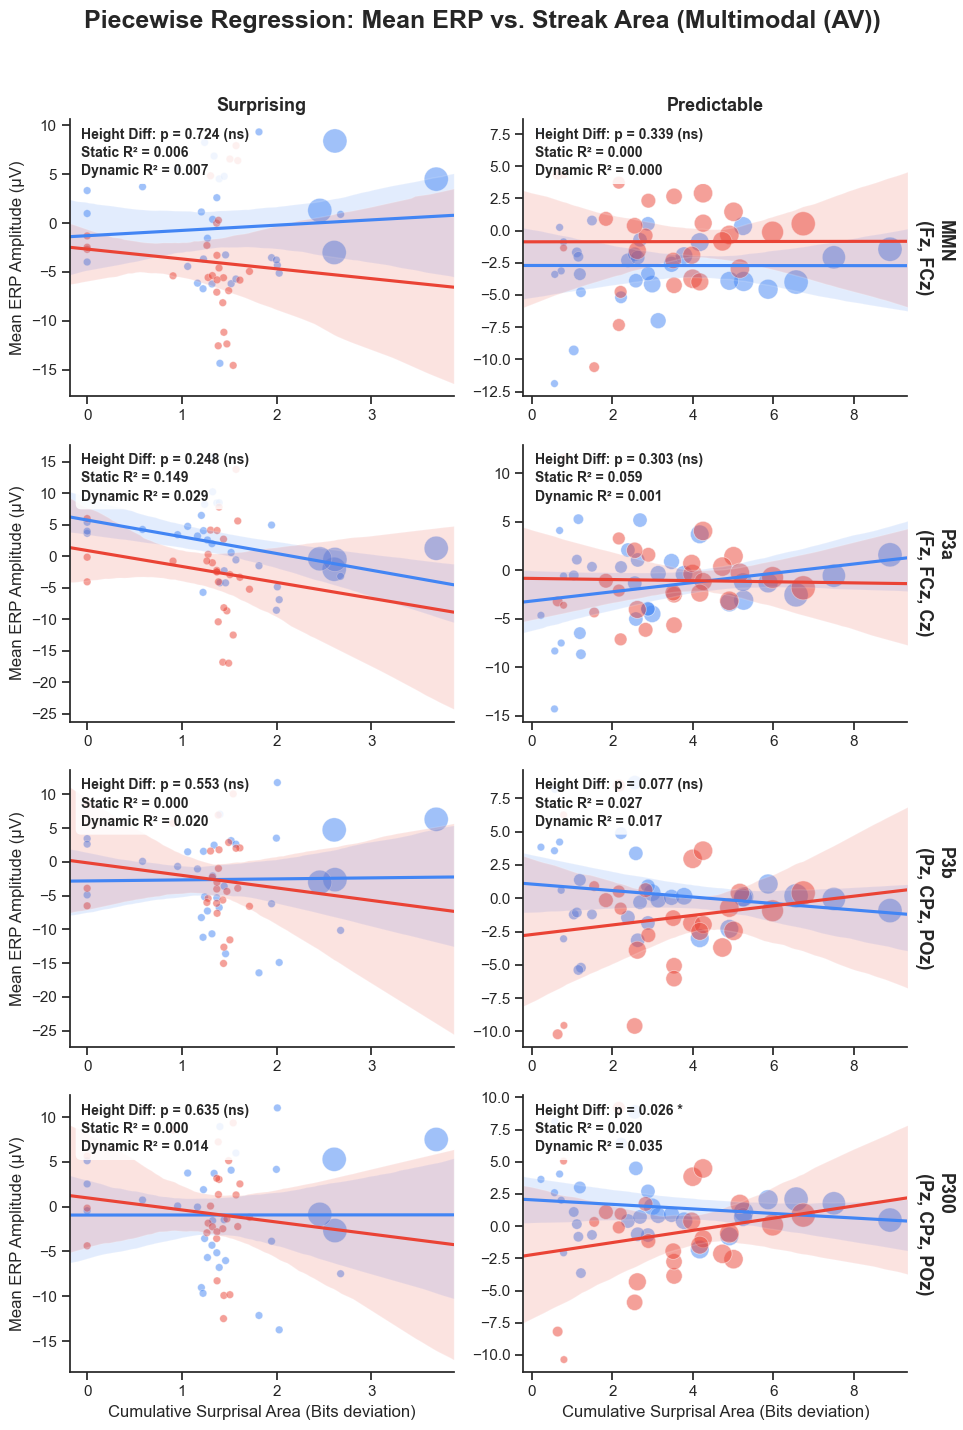

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print("Beregner streaks (kæder), kumulativt areal og gennemsnitlig ERP...")

# 1. Hent metadata 
df_plot = epochs_correct.metadata.copy()

# Omdøb SV til VS hvis nødvendigt
df_plot['deviant_type'] = df_plot['deviant_type'].replace({'SV': 'VS'})

# Definer ROIs
rois_by_modality = {
    'AS': {'MMN': ['Fz'], 'P3a': ['Fz', 'FCz', 'Cz'], 'P3b': ['Pz', 'CPz', 'POz'], 'P300': ['Cz']},
    'VS': {'MMN': ['Oz'], 'P3a': ['Fz', 'FCz', 'Cz'], 'P3b': ['Pz', 'CPz', 'POz'], 'P300': ['Oz', 'Pz']},
    'AV': {'MMN': ['Fz', 'FCz'], 'P3a': ['Fz', 'FCz', 'Cz'], 'P3b': ['Pz', 'CPz', 'POz'], 'P300': ['Pz', 'CPz', 'POz']}
}

def format_p(p):
    if p < 0.001: return "p < 0.001 ***"
    elif p < 0.01: return f"p = {p:.3f} **"
    elif p < 0.05: return f"p = {p:.3f} *"
    else: return f"p = {p:.3f} (ns)"

# 2. Kør loop der genererer plots for hver modalitet
for modality in ['AS', 'VS', 'AV']:
    df_mod = df_plot[df_plot['deviant_type'] == modality].copy()
    
    if len(df_mod) == 0:
        continue
    
    # --------------------------------------------------------------------------
    # DATABEHANDLING: BEREGN STREAKS OG AREAL (Som i R-scriptet)
    # --------------------------------------------------------------------------
    # A. Definer over/under threshold (1 bit)
    df_mod['status'] = np.where(df_mod['surprisal'] >= 1.0, 'Surprising', 'Predictable')
    
    # B. Beregn afvigelse fra threshold (bruges til at regne areal)
    df_mod['deviation'] = np.abs(df_mod['surprisal'] - 1.0)
    
    # C. Find ud af hvornår en ny streak (kæde) starter. 
    # En kæde brydes når 'status' eller 'block_type' skifter.
    chain_breaks = (df_mod['status'] != df_mod['status'].shift()) | (df_mod['block_type'] != df_mod['block_type'].shift())
    df_mod['chain_id'] = chain_breaks.cumsum()
    
    # D. Aggregér dataen (Saml hver streak til én række)
    df_chains = df_mod.groupby('chain_id').agg({
        'status': 'first',
        'block_type': 'first',
        'surprisal': 'count', # Tæller antal trials i streaken (Chain Length)
        'deviation': 'sum',   # Summen af afvigelsen = Kumulativt Surprisal Area
        'amp_MMN': 'mean',    # Gennemsnitlig ERP for streaken
        'amp_P3a': 'mean',
        'amp_P3b': 'mean',
        'amp_P300': 'mean'
    }).rename(columns={'surprisal': 'trial_count', 'deviation': 'plot_x'}).reset_index()
    
    # --------------------------------------------------------------------------
    # PLOTTING
    # --------------------------------------------------------------------------
    # Omdan til Tidy Data Format for Seaborn
    df_long = pd.melt(
        df_chains, 
        id_vars=['plot_x', 'block_type', 'status', 'trial_count'], 
        value_vars=['amp_MMN', 'amp_P3a', 'amp_P3b', 'amp_P300'],
        var_name='ROI', 
        value_name='mean_erp'
    )
    
    def map_roi_name(roi_col):
        base_roi = roi_col.replace('amp_', '')
        channels = ", ".join(rois_by_modality[modality][base_roi])
        return f"{base_roi}\n({channels})"
        
    df_long['ROI'] = df_long['ROI'].apply(map_roi_name)
    
    # Byg Facet Grid
    sns.set_theme(style="ticks") 
    g = sns.FacetGrid(
        df_long,
        col="status",           
        row="ROI",              
        hue="block_type",
        sharex=False,           
        sharey=False,           
        height=3.5,             
        aspect=1.4,             
        palette={'Static': '#4285F4', 'Dynamic': '#EA4335'},
        margin_titles=True
    )
    
    # Tilføj bobler (størrelse = kædens længde)
    g.map_dataframe(
        sns.scatterplot,
        x="plot_x",
        y="mean_erp",
        size="trial_count",     
        sizes=(30, 300),        
        alpha=0.5,
        legend=False            
    )
    
    # Tilføj regressionslinjer
    g.map_dataframe(
        sns.regplot,
        x="plot_x",
        y="mean_erp",
        scatter=False,          
        truncate=False
    )
    
    # Udregn statistik og tilføj tekstbokse
    for (row_val, col_val), ax in g.axes_dict.items():
        data_ax = df_long[(df_long['ROI'] == row_val) & (df_long['status'] == col_val)].dropna(subset=['plot_x', 'mean_erp'])
        
        # Vi kræver mindst 4 punkter for at køre regression på aggregeret data
        if len(data_ax) > 4:
            d_stat = data_ax[data_ax['block_type'] == 'Static']
            d_dyn = data_ax[data_ax['block_type'] == 'Dynamic']
            text_lines = []
            
            # Højdeforskel
            try:
                model = smf.ols("mean_erp ~ plot_x * block_type", data=data_ax).fit()
                int_keys = [k for k in model.pvalues.keys() if 'block_type' in k and ':' not in k]
                if int_keys:
                    p_intercept = model.pvalues[int_keys[0]]
                    text_lines.append(f"Height Diff: {format_p(p_intercept)}")
            except Exception:
                pass
                
            # Individuel R²
            try:
                r2_stat = smf.ols("mean_erp ~ plot_x", data=d_stat).fit().rsquared if len(d_stat) > 2 else 0
                r2_dyn = smf.ols("mean_erp ~ plot_x", data=d_dyn).fit().rsquared if len(d_dyn) > 2 else 0
                text_lines.append(f"Static R² = {r2_stat:.3f}")
                text_lines.append(f"Dynamic R² = {r2_dyn:.3f}")
            except Exception:
                pass
                
            if text_lines:
                text_str = '\n'.join(text_lines)
                ax.text(0.03, 0.97, text_str, transform=ax.transAxes,
                        va='top', ha='left', fontsize=10, fontweight='bold', linespacing=1.4,
                        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.4'))

    # Formatering af akser og titler
    g.set_axis_labels("Cumulative Surprisal Area (Bits deviation)", "Mean ERP Amplitude (µV)")
    g.set_titles(row_template="{row_name}", col_template="{col_name}", size=13, weight='bold')
    
    sns.despine()
    
    modality_full = {'AS': 'Auditory (AS)', 'VS': 'Visual (VS)', 'AV': 'Multimodal (AV)'}[modality]
    g.fig.suptitle(f"Piecewise Regression: Mean ERP vs. Streak Area ({modality_full})", y=1.02, fontsize=18, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

Samler ALLE trials på tvers av modaliteter i 4 ROIs...


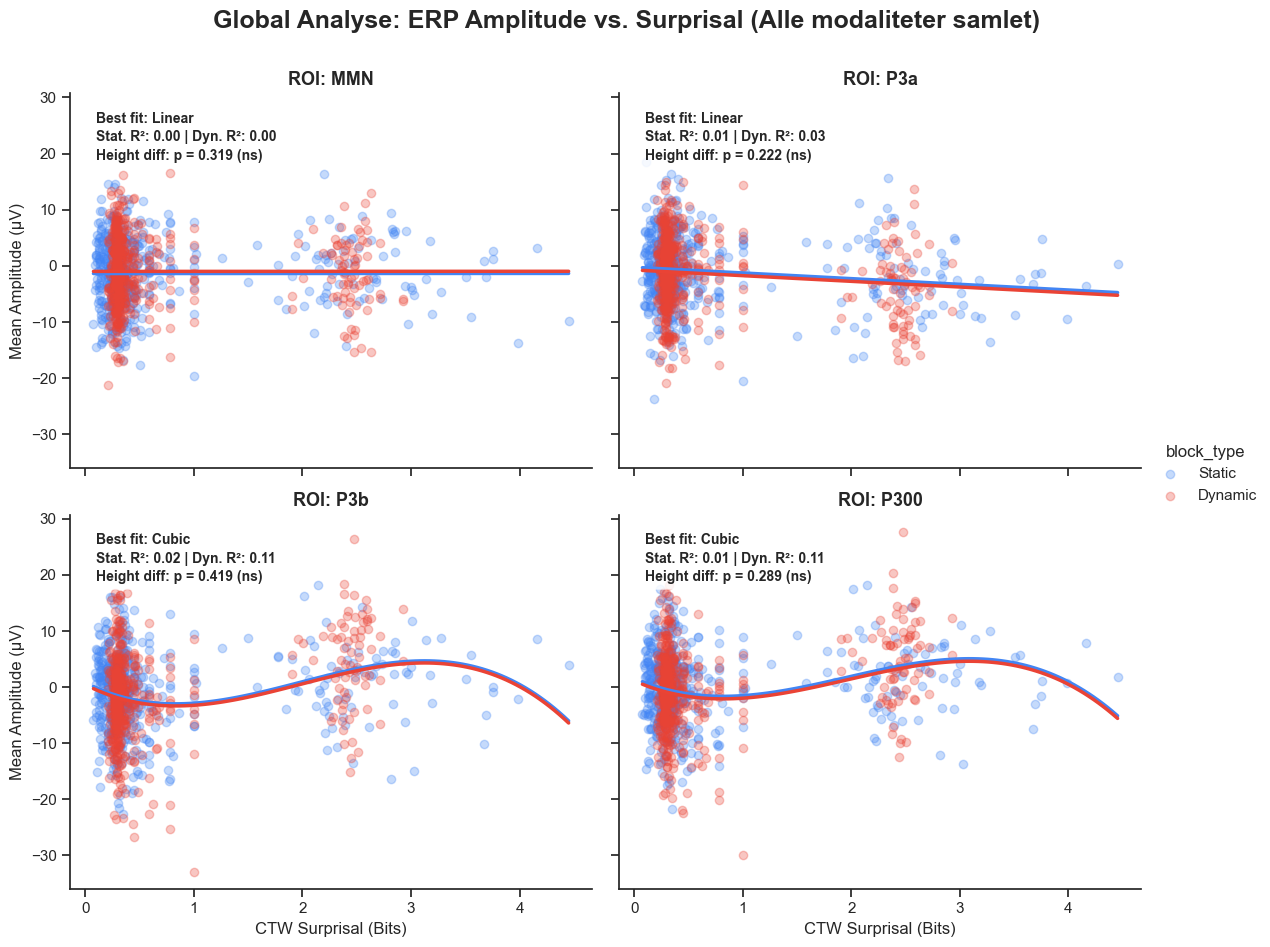

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print("Samler ALLE trials på tvers av modaliteter i 4 ROIs...")

# 1. Hent metadata 
df_plot = epochs_correct.metadata.copy()

# (Valgfritt filter) Hvis du kun vil se på deviants i den samlede analysen, fjern # foran linjen under:
# df_plot = df_plot[df_plot['stimulus_state'] == 'deviant']

# 2. Omdan til Tidy Data for HELE datasettet under ett
df_long = pd.melt(
    df_plot, 
    id_vars=['surprisal', 'block_type'], 
    value_vars=['amp_MMN', 'amp_P3a', 'amp_P3b', 'amp_P300'],
    var_name='ROI', 
    value_name='Amplitude_uV'
)

# Gjør ROI-navnene penere til plottet
df_long['ROI'] = df_long['ROI'].str.replace('amp_', '')

# 3. Bygg et 2x2 Facet Grid for de 4 ROI-ene
sns.set_theme(style="ticks") 
g = sns.lmplot(
    data=df_long,
    x='surprisal', 
    y='Amplitude_uV', 
    col='ROI',             
    hue='block_type',      
    col_wrap=2,            
    scatter_kws={'alpha': 0.3},
    fit_reg=False,         # Vi regner ut ekte matematiske best-fits (AIC) manuelt
    height=4.5,            
    aspect=1.3,            
    palette={'Static': '#4285F4', 'Dynamic': '#EA4335'}
)

# 4. Regn ut statistikk og tegn kurver for hver av de 4 ROI-ene
for ax, roi_name in zip(g.axes.flat, g.col_names):
    data_ax = df_long[df_long['ROI'] == roi_name].dropna(subset=['surprisal', 'Amplitude_uV']).copy()
    
    if len(data_ax) > 5:
        d_stat = data_ax[data_ax['block_type'] == 'Static']
        d_dyn = data_ax[data_ax['block_type'] == 'Dynamic']
        
        formulas = {
            "Linear": "Amplitude_uV ~ surprisal + block_type",
            "Quad": "Amplitude_uV ~ surprisal + I(surprisal**2) + block_type",
            "Cubic": "Amplitude_uV ~ surprisal + I(surprisal**2) + I(surprisal**3) + block_type"
        }
        
        best_aic = float('inf')
        best_model = None
        best_shape = ""
        
        # Finn modellen med lavest AIC (Beste Fit)
        for shape, formula in formulas.items():
            try:
                m_fit = smf.ols(formula, data=data_ax).fit()
                if m_fit.aic < best_aic:
                    best_aic = m_fit.aic
                    best_model = m_fit
                    best_shape = shape
            except Exception:
                pass
        
        if best_model is not None:
            # -- TEGN DE MATEMATISKE KURVENE --
            x_vals = np.linspace(data_ax['surprisal'].min(), data_ax['surprisal'].max(), 100)
            
            if len(d_stat) > 3:
                pred_stat = best_model.predict(pd.DataFrame({'surprisal': x_vals, 'block_type': 'Static'}))
                ax.plot(x_vals, pred_stat, color='#4285F4', linewidth=2.5)
            
            if len(d_dyn) > 3:
                pred_dyn = best_model.predict(pd.DataFrame({'surprisal': x_vals, 'block_type': 'Dynamic'}))
                ax.plot(x_vals, pred_dyn, color='#EA4335', linewidth=2.5)

            # -- BEREGN OG INDSÆT TEKSTBOKS --
            text_lines = [f"Best fit: {best_shape}"]
            
            if best_shape == "Linear": sub_f = "Amplitude_uV ~ surprisal"
            elif best_shape == "Quad": sub_f = "Amplitude_uV ~ surprisal + I(surprisal**2)"
            else: sub_f = "Amplitude_uV ~ surprisal + I(surprisal**2) + I(surprisal**3)"
            
            try:
                r2_stat = smf.ols(sub_f, data=d_stat).fit().rsquared if len(d_stat) > 3 else 0
                r2_dyn = smf.ols(sub_f, data=d_dyn).fit().rsquared if len(d_dyn) > 3 else 0
                text_lines.append(f"Stat. R²: {r2_stat:.2f} | Dyn. R²: {r2_dyn:.2f}")
            except Exception:
                pass
            
            # Test høydeforskjellen (Main effect of block_type)
            try:
                int_keys = [k for k in best_model.pvalues.keys() if 'block_type' in k and ':' not in k]
                if int_keys:
                    p_intercept = best_model.pvalues[int_keys[0]]
                    
                    if p_intercept < 0.001: sig_star_int = "***"
                    elif p_intercept < 0.01: sig_star_int = "**"
                    elif p_intercept < 0.05: sig_star_int = "*"
                    else: sig_star_int = "(ns)"
                    
                    if p_intercept < 0.001:
                        text_lines.append("Height diff: p < 0.001 ***")
                    else:
                        text_lines.append(f"Height diff: p = {p_intercept:.3f} {sig_star_int}")
            except Exception:
                pass
            
            text_str = '\n'.join(text_lines)
            ax.text(0.05, 0.95, text_str, transform=ax.transAxes,
                    va='top', ha='left', fontsize=10, fontweight='bold', linespacing=1.4,
                    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.4'))

# Formatering av akser og titler
g.set_axis_labels("CTW Surprisal (Bits)", "Mean Amplitude (µV)")
g.set_titles(col_template="ROI: {col_name}", size=13, weight='bold') 
sns.despine()

g.fig.suptitle("Global Analyse: ERP Amplitude vs. Surprisal (Alle modaliteter samlet)", y=1.05, fontsize=18, fontweight='bold')

plt.show()

Beregner streaks (kæder), kumulativt areal og gennemsnitlig ERP for HELE datasættet...


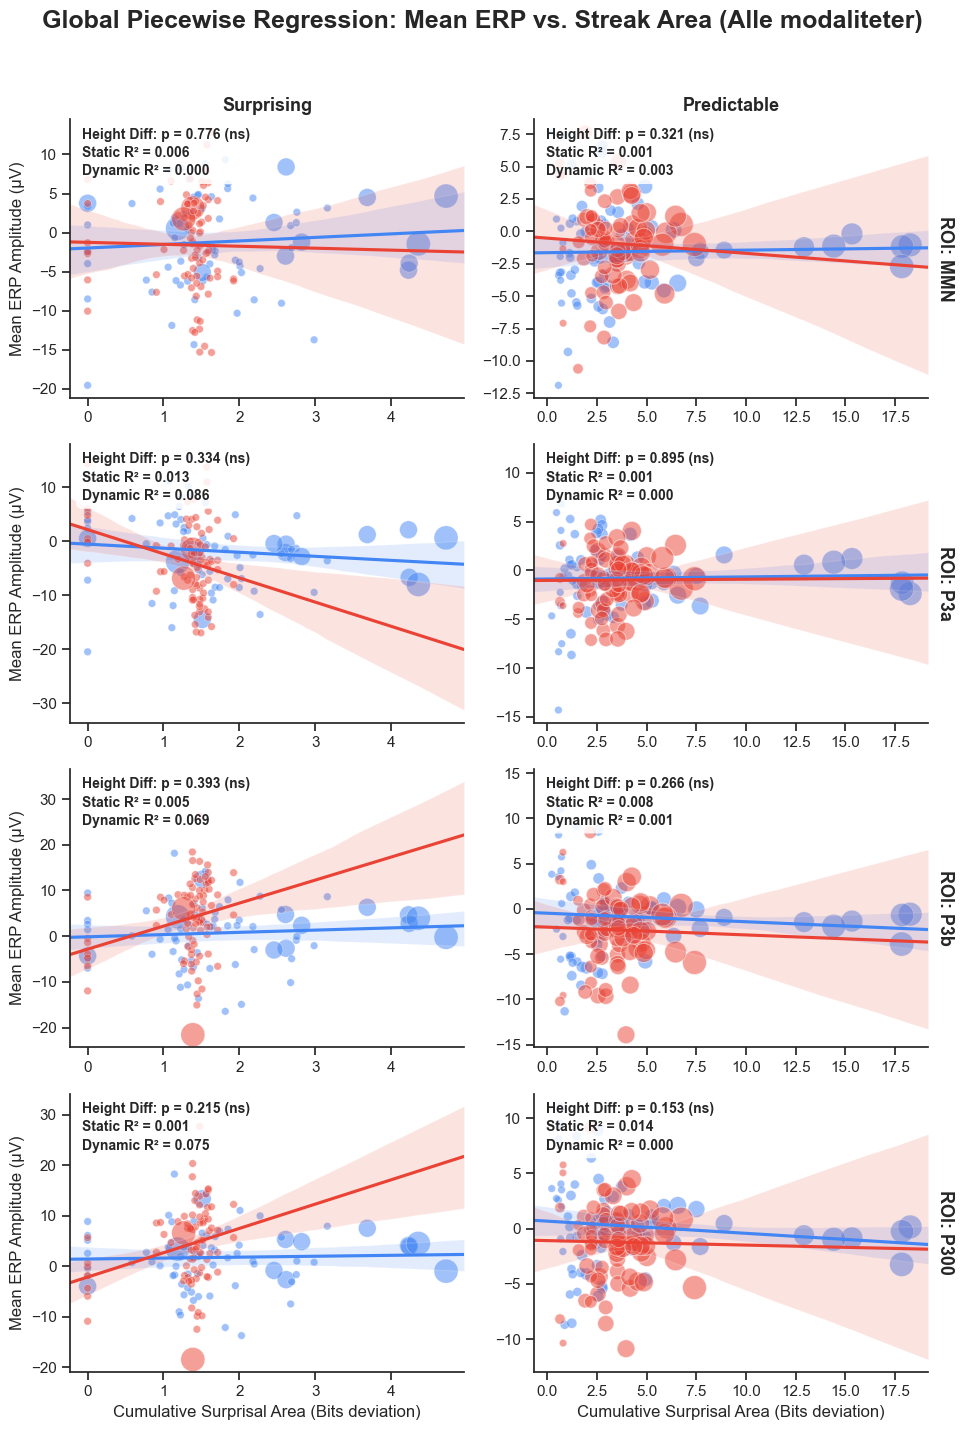

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print("Beregner streaks (kæder), kumulativt areal og gennemsnitlig ERP for HELE datasættet...")

# 1. Hent metadata 
df_plot = epochs_correct.metadata.copy()

# Omdøb SV til VS hvis nødvendigt
df_plot['deviant_type'] = df_plot['deviant_type'].replace({'SV': 'VS'})

def format_p(p):
    if p < 0.001: return "p < 0.001 ***"
    elif p < 0.01: return f"p = {p:.3f} **"
    elif p < 0.05: return f"p = {p:.3f} *"
    else: return f"p = {p:.3f} (ns)"

# Vi arbejder nu direkte på hele datasættet uden at loope
df_mod = df_plot.copy()

# --------------------------------------------------------------------------
# DATABEHANDLING: BEREGN STREAKS OG AREAL 
# --------------------------------------------------------------------------
# A. Definer over/under threshold (1 bit)
df_mod['status'] = np.where(df_mod['surprisal'] >= 1.0, 'Surprising', 'Predictable')

# B. Beregn afvigelse fra threshold (bruges til at regne areal)
df_mod['deviation'] = np.abs(df_mod['surprisal'] - 1.0)

# C. Find ud af hvornår en ny streak (kæde) starter. 
# En kæde brydes når 'status', 'block_type' ELLER 'deviant_type' skifter.
chain_breaks = (
    (df_mod['status'] != df_mod['status'].shift()) | 
    (df_mod['block_type'] != df_mod['block_type'].shift()) |
    (df_mod['deviant_type'] != df_mod['deviant_type'].shift())
)
df_mod['chain_id'] = chain_breaks.cumsum()

# D. Aggregér dataen (Saml hver streak til én række)
df_chains = df_mod.groupby('chain_id').agg({
    'status': 'first',
    'block_type': 'first',
    'surprisal': 'count', # Tæller antal trials i streaken (Chain Length)
    'deviation': 'sum',   # Summen af afvigelsen = Kumulativt Surprisal Area
    'amp_MMN': 'mean',    # Gennemsnitlig ERP for streaken
    'amp_P3a': 'mean',
    'amp_P3b': 'mean',
    'amp_P300': 'mean'
}).rename(columns={'surprisal': 'trial_count', 'deviation': 'plot_x'}).reset_index()

# --------------------------------------------------------------------------
# PLOTTING
# --------------------------------------------------------------------------
# Omdan til Tidy Data Format for Seaborn
df_long = pd.melt(
    df_chains, 
    id_vars=['plot_x', 'block_type', 'status', 'trial_count'], 
    value_vars=['amp_MMN', 'amp_P3a', 'amp_P3b', 'amp_P300'],
    var_name='ROI', 
    value_name='mean_erp'
)

# Gør ROI-navne pæne (fjerner 'amp_')
df_long['ROI'] = df_long['ROI'].str.replace('amp_', '')

# Byg Facet Grid (Nu med alt data!)
sns.set_theme(style="ticks") 
g = sns.FacetGrid(
    df_long,
    col="status",           
    row="ROI",              
    hue="block_type",
    sharex=False,           
    sharey=False,           
    height=3.5,             
    aspect=1.4,             
    palette={'Static': '#4285F4', 'Dynamic': '#EA4335'},
    margin_titles=True
)

# Tilføj bobler (størrelse = kædens længde)
g.map_dataframe(
    sns.scatterplot,
    x="plot_x",
    y="mean_erp",
    size="trial_count",     
    sizes=(30, 300),        
    alpha=0.5,
    legend=False            
)

# Tilføj regressionslinjer
g.map_dataframe(
    sns.regplot,
    x="plot_x",
    y="mean_erp",
    scatter=False,          
    truncate=False
)

# Udregn statistik og tilføj tekstbokse
for (row_val, col_val), ax in g.axes_dict.items():
    data_ax = df_long[(df_long['ROI'] == row_val) & (df_long['status'] == col_val)].dropna(subset=['plot_x', 'mean_erp'])
    
    # Vi kræver mindst 4 punkter for at køre regression på aggregeret data
    if len(data_ax) > 4:
        d_stat = data_ax[data_ax['block_type'] == 'Static']
        d_dyn = data_ax[data_ax['block_type'] == 'Dynamic']
        text_lines = []
        
        # Højdeforskel
        try:
            model = smf.ols("mean_erp ~ plot_x * block_type", data=data_ax).fit()
            int_keys = [k for k in model.pvalues.keys() if 'block_type' in k and ':' not in k]
            if int_keys:
                p_intercept = model.pvalues[int_keys[0]]
                text_lines.append(f"Height Diff: {format_p(p_intercept)}")
        except Exception:
            pass
            
        # Individuel R²
        try:
            r2_stat = smf.ols("mean_erp ~ plot_x", data=d_stat).fit().rsquared if len(d_stat) > 2 else 0
            r2_dyn = smf.ols("mean_erp ~ plot_x", data=d_dyn).fit().rsquared if len(d_dyn) > 2 else 0
            text_lines.append(f"Static R² = {r2_stat:.3f}")
            text_lines.append(f"Dynamic R² = {r2_dyn:.3f}")
        except Exception:
            pass
            
        if text_lines:
            text_str = '\n'.join(text_lines)
            ax.text(0.03, 0.97, text_str, transform=ax.transAxes,
                    va='top', ha='left', fontsize=10, fontweight='bold', linespacing=1.4,
                    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.4'))

# Formatering af akser og titler
g.set_axis_labels("Cumulative Surprisal Area (Bits deviation)", "Mean ERP Amplitude (µV)")
g.set_titles(row_template="ROI: {row_name}", col_template="{col_name}", size=13, weight='bold')

sns.despine()

g.fig.suptitle("Global Piecewise Regression: Mean ERP vs. Streak Area (Alle modaliteter)", y=1.02, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()